<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_consensus_memory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

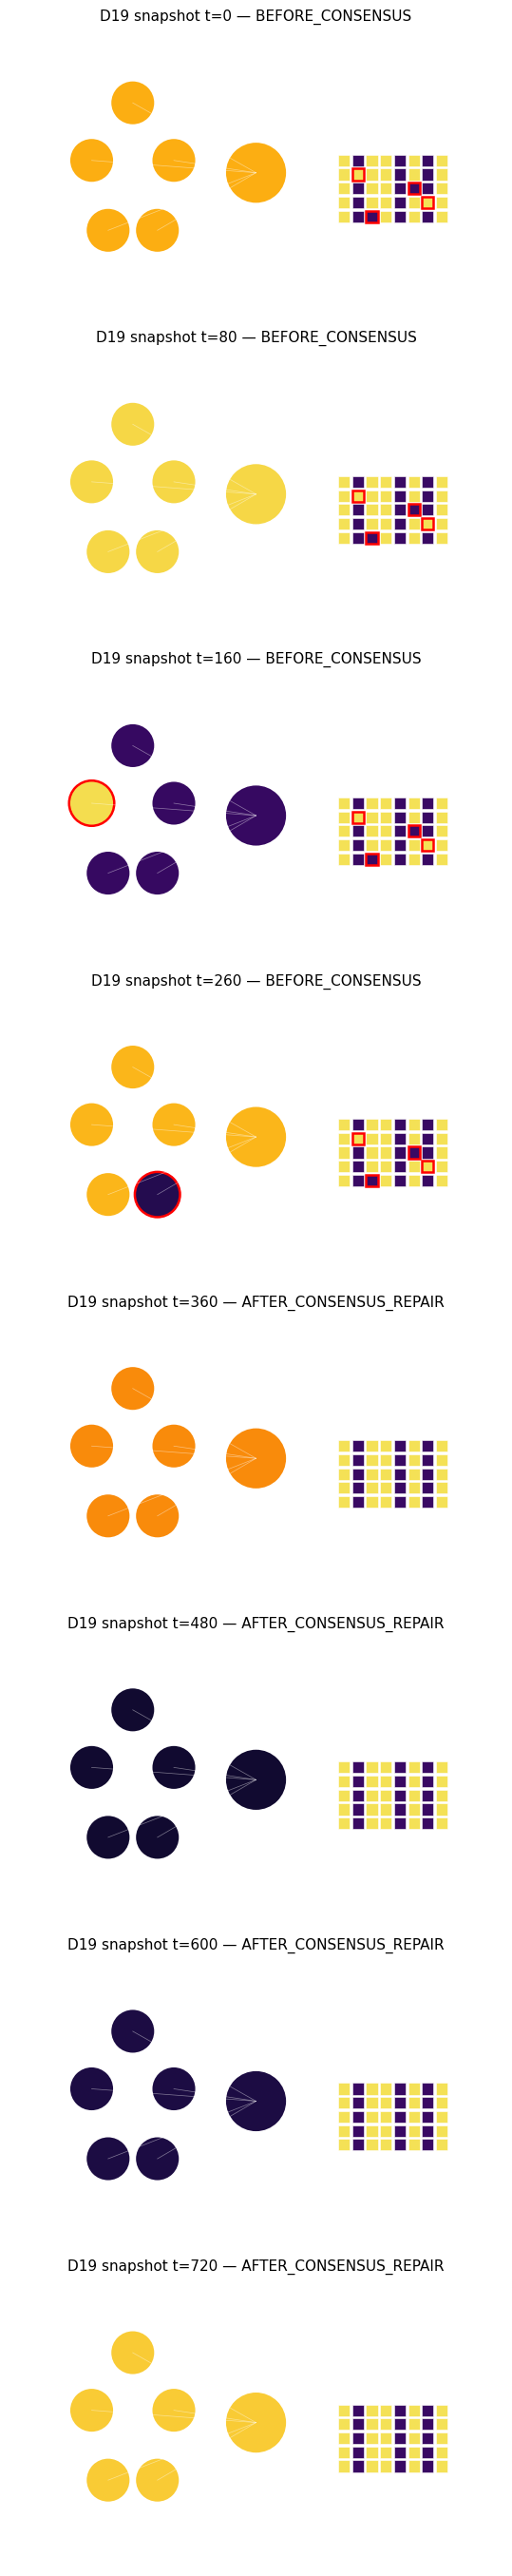

STATE: CONSENSUS_MEMORY_LOCKED
input sequence:          10110101
consensus sequence:      10110101
cells:                   5
consensus threshold:     3
total repaired slots:    4
mean initial accuracy:   0.9
worst initial accuracy:  0.875
consensus accuracy:      1.0
mean repaired accuracy:  1.0

Consensus vote table:


,STATE,MEMORY_SLOT,INPUT_BIT,CELL_VALUES,VOTE_SUM,CONSENSUS_BIT,MATCH
0,D19_CONSENSUS_MEMORY,0,1,11111,5,1,1
1,D19_CONSENSUS_MEMORY,1,0,01000,1,0,1
2,D19_CONSENSUS_MEMORY,2,1,11110,4,1,1
3,D19_CONSENSUS_MEMORY,3,1,11111,5,1,1
4,D19_CONSENSUS_MEMORY,4,0,00000,0,0,1
5,D19_CONSENSUS_MEMORY,5,1,11011,4,1,1
6,D19_CONSENSUS_MEMORY,6,0,00010,1,0,1
7,D19_CONSENSUS_MEMORY,7,1,11111,5,1,1



Cell repair table:


,STATE,CELL,BEFORE_SEQUENCE,AFTER_SEQUENCE,CHANGED_SLOTS,INITIAL_ACCURACY,REPAIRED_ACCURACY,REPAIRED_MATCH
0,D19_CONSENSUS_MEMORY,MEM_CELL_A,10110101,10110101,none,1.000,1.0,1
1,D19_CONSENSUS_MEMORY,MEM_CELL_B,11110101,10110101,1,0.875,1.0,1
2,D19_CONSENSUS_MEMORY,MEM_CELL_C,10110001,10110101,5,0.875,1.0,1
3,D19_CONSENSUS_MEMORY,MEM_CELL_D,10110111,10110101,6,0.875,1.0,1
4,D19_CONSENSUS_MEMORY,MEM_CELL_E,10010101,10110101,2,0.875,1.0,1



Summary:


,STATE,RESULT,INPUT_SEQUENCE,CONSENSUS_SEQUENCE,CELLS,CONSENSUS_THRESHOLD,TOTAL_REPAIRED_SLOTS,MEAN_INITIAL_ACCURACY,WORST_INITIAL_ACCURACY,CONSENSUS_ACCURACY,MEAN_REPAIRED_ACCURACY
0,D19_CONSENSUS_MEMORY,CONSENSUS_MEMORY_LOCKED,10110101,10110101,5,3,4,0.9,0.875,1.0,1.0


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

# ============================================================
# D19_CONSENSUS_MEMORY
# Multi-cell memory consensus and repair
#
# Goal:
# multiple bounded memory cells store noisy copies of the same sequence
# -> compare memory slots across cells
# -> compute majority consensus
# -> repair all cells to the shared consensus state
# ============================================================

np.random.seed(19)

STATE = "D19_CONSENSUS_MEMORY"

input_sequence = "10110101"
num_cells = 5
consensus_threshold = 3

cell_names = [
    "MEM_CELL_A",
    "MEM_CELL_B",
    "MEM_CELL_C",
    "MEM_CELL_D",
    "MEM_CELL_E",
]

# Each cell has a small local memory error.
# No bit position has enough errors to defeat majority consensus.
initial_memory = {
    "MEM_CELL_A": list(map(int, input_sequence)),
    "MEM_CELL_B": list(map(int, input_sequence)),
    "MEM_CELL_C": list(map(int, input_sequence)),
    "MEM_CELL_D": list(map(int, input_sequence)),
    "MEM_CELL_E": list(map(int, input_sequence)),
}

# Local damage: one wrong bit per selected cell.
damage_plan = {
    "MEM_CELL_B": [1],
    "MEM_CELL_C": [5],
    "MEM_CELL_D": [6],
    "MEM_CELL_E": [2],
}

for cell, damaged_slots in damage_plan.items():
    for slot in damaged_slots:
        initial_memory[cell][slot] = 1 - initial_memory[cell][slot]


def bits_to_string(bits):
    return "".join(str(int(x)) for x in bits)


def accuracy(bits, target):
    return float(np.mean(np.array(bits) == np.array(target)))


target_bits = list(map(int, input_sequence))

# ------------------------------------------------------------
# Consensus calculation
# ------------------------------------------------------------

consensus_bits = []

consensus_rows = []
for slot in range(len(input_sequence)):
    slot_values = [initial_memory[cell][slot] for cell in cell_names]
    vote_sum = int(sum(slot_values))
    consensus_bit = 1 if vote_sum >= consensus_threshold else 0
    consensus_bits.append(consensus_bit)

    consensus_rows.append({
        "STATE": STATE,
        "MEMORY_SLOT": slot,
        "INPUT_BIT": target_bits[slot],
        "CELL_VALUES": bits_to_string(slot_values),
        "VOTE_SUM": vote_sum,
        "CONSENSUS_BIT": consensus_bit,
        "MATCH": int(consensus_bit == target_bits[slot])
    })

consensus_sequence = bits_to_string(consensus_bits)

# ------------------------------------------------------------
# Repair all memory cells to consensus
# ------------------------------------------------------------

repaired_memory = {}
repair_rows = []

for cell in cell_names:
    repaired_memory[cell] = consensus_bits.copy()

    before_bits = initial_memory[cell]
    before_sequence = bits_to_string(before_bits)
    after_sequence = bits_to_string(repaired_memory[cell])

    changed_slots = [
        i for i in range(len(input_sequence))
        if before_bits[i] != repaired_memory[cell][i]
    ]

    repair_rows.append({
        "STATE": STATE,
        "CELL": cell,
        "BEFORE_SEQUENCE": before_sequence,
        "AFTER_SEQUENCE": after_sequence,
        "CHANGED_SLOTS": ",".join(map(str, changed_slots)) if changed_slots else "none",
        "INITIAL_ACCURACY": round(accuracy(before_bits, target_bits), 3),
        "REPAIRED_ACCURACY": round(accuracy(repaired_memory[cell], target_bits), 3),
        "REPAIRED_MATCH": int(repaired_memory[cell] == target_bits)
    })

df_consensus = pd.DataFrame(consensus_rows)
df_repair = pd.DataFrame(repair_rows)

initial_accuracies = [
    accuracy(initial_memory[cell], target_bits)
    for cell in cell_names
]

repaired_accuracies = [
    accuracy(repaired_memory[cell], target_bits)
    for cell in cell_names
]

total_changed_slots = sum(
    initial_memory[cell][slot] != repaired_memory[cell][slot]
    for cell in cell_names
    for slot in range(len(input_sequence))
)

consensus_accuracy = accuracy(consensus_bits, target_bits)
mean_initial_accuracy = float(np.mean(initial_accuracies))
worst_initial_accuracy = float(np.min(initial_accuracies))
mean_repaired_accuracy = float(np.mean(repaired_accuracies))

result = (
    "CONSENSUS_MEMORY_LOCKED"
    if consensus_accuracy == 1.0 and mean_repaired_accuracy == 1.0
    else "CONSENSUS_MEMORY_PARTIAL"
)

df_summary = pd.DataFrame([{
    "STATE": STATE,
    "RESULT": result,
    "INPUT_SEQUENCE": input_sequence,
    "CONSENSUS_SEQUENCE": consensus_sequence,
    "CELLS": num_cells,
    "CONSENSUS_THRESHOLD": consensus_threshold,
    "TOTAL_REPAIRED_SLOTS": int(total_changed_slots),
    "MEAN_INITIAL_ACCURACY": round(mean_initial_accuracy, 3),
    "WORST_INITIAL_ACCURACY": round(worst_initial_accuracy, 3),
    "CONSENSUS_ACCURACY": round(consensus_accuracy, 3),
    "MEAN_REPAIRED_ACCURACY": round(mean_repaired_accuracy, 3),
}])

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

def bit_color(bit, intensity=1.0):
    if bit == 1:
        return plt.cm.inferno(0.72 + 0.20 * intensity)
    return plt.cm.inferno(0.08 + 0.10 * intensity)


def draw_memory_matrix(ax, x0, y0, memory_dict, title, mark_errors=True):
    cell_w = 0.28
    gap = 0.06

    ax.text(x0, y0 + 2.15, title, color="white", fontsize=8, ha="left")

    for row, cell in enumerate(cell_names):
        bits = memory_dict[cell]
        for col, bit in enumerate(bits):
            x = x0 + col * (cell_w + gap)
            y = y0 + (num_cells - 1 - row) * (cell_w + gap)

            is_error = bits[col] != target_bits[col]
            edge = "red" if mark_errors and is_error else "white"
            lw = 1.8 if mark_errors and is_error else 0.4

            rect = Rectangle(
                (x, y),
                cell_w,
                cell_w,
                facecolor=bit_color(bit),
                edgecolor=edge,
                linewidth=lw
            )
            ax.add_patch(rect)


def draw_snapshot(ax, t, phase, repaired=False):
    ax.set_facecolor("black")
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 7)
    ax.set_aspect("equal")
    ax.axis("off")

    wave = 0.5 + 0.5 * np.sin(2 * np.pi * phase)
    slot = min(len(input_sequence) - 1, int((t / 100) % len(input_sequence)))

    active_memory = repaired_memory if repaired else initial_memory

    positions = {
        "MEM_CELL_A": (3.0, 5.2),
        "MEM_CELL_B": (2.0, 3.8),
        "MEM_CELL_C": (4.0, 3.8),
        "MEM_CELL_D": (2.4, 2.1),
        "MEM_CELL_E": (3.6, 2.1),
    }

    # Draw memory cells
    for cell, (x, y) in positions.items():
        bit = active_memory[cell][slot]
        color = bit_color(bit, wave)

        is_error = active_memory[cell][slot] != target_bits[slot]
        edge = "red" if is_error and not repaired else "white"

        ax.add_patch(
            Circle(
                (x, y),
                0.55,
                facecolor=color,
                edgecolor=edge,
                linewidth=1.8
            )
        )

        ax.text(x, y - 0.85, cell[-1], color="white", fontsize=8, ha="center")

    # Consensus center
    consensus_bit = consensus_bits[slot]
    ax.add_patch(
        Circle(
            (6.0, 3.5),
            0.75,
            facecolor=bit_color(consensus_bit, wave),
            edgecolor="white",
            linewidth=1.2
        )
    )
    ax.text(6.0, 2.55, "CONSENSUS", color="white", fontsize=8, ha="center")

    # Links
    for x, y in positions.values():
        ax.plot([x, 6.0], [y, 3.5], color="white", linewidth=0.5, alpha=0.45)

    # Memory matrix
    draw_memory_matrix(
        ax,
        x0=8.0,
        y0=2.3,
        memory_dict=active_memory,
        title="repaired memory" if repaired else "initial damaged memory",
        mark_errors=not repaired
    )

    ax.set_title(
        f"D19 snapshot t={t} — {'AFTER_CONSENSUS_REPAIR' if repaired else 'BEFORE_CONSENSUS'}",
        fontsize=11,
        color="black"
    )


snapshots = [
    (0, 0.00, False),
    (80, 0.15, False),
    (160, 0.32, False),
    (260, 0.48, False),
    (360, 0.64, True),
    (480, 0.80, True),
    (600, 0.95, True),
    (720, 0.10, True),
]

fig, axes = plt.subplots(len(snapshots), 1, figsize=(7, 3.4 * len(snapshots)))

for ax, (t, phase, repaired) in zip(axes, snapshots):
    draw_snapshot(ax, t, phase, repaired)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print(f"STATE: {result}")
print(f"input sequence:          {input_sequence}")
print(f"consensus sequence:      {consensus_sequence}")
print(f"cells:                   {num_cells}")
print(f"consensus threshold:     {consensus_threshold}")
print(f"total repaired slots:    {total_changed_slots}")
print(f"mean initial accuracy:   {round(mean_initial_accuracy, 3)}")
print(f"worst initial accuracy:  {round(worst_initial_accuracy, 3)}")
print(f"consensus accuracy:      {round(consensus_accuracy, 3)}")
print(f"mean repaired accuracy:  {round(mean_repaired_accuracy, 3)}")

print("\nConsensus vote table:")
display(df_consensus)

print("\nCell repair table:")
display(df_repair)

print("\nSummary:")
display(df_summary)